# Phase 4: Advanced Modeling + Model Comparison

**Project:** Credit Default Risk Modeling  
**Phase:** 4 — Random Forest + XGBoost + Full Comparison  

---

## Goal

We already have a statistically rigorous Logistic Regression baseline.  
Now we ask: **Can tree-based models do better?**  
And more importantly: **Is the performance gain worth the interpretability loss?**

This is the conversation senior data scientists have in practice.

---

## Models We'll Build

| Model | Type | Strength |
|---|---|---|
| Logistic Regression | Linear | Interpretable, statistically rigorous |
| Random Forest | Ensemble (Bagging) | Handles non-linearity, robust |
| XGBoost | Ensemble (Boosting) | Best raw performance, industry standard |

##  Evaluation Metrics (Finance-Focused)

| Metric | Why It Matters in Finance |
|---|---|
| ROC-AUC | Overall discrimination |
| KS Statistic | Primary bank model metric |
| Gini Coefficient | Regulatory reporting |
| Precision-Recall AUC | Performance under class imbalance |
| Calibration (Brier) | Risk pricing accuracy |
| F1 Score | Balance of precision & recall |

## 1 Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Models
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, confusion_matrix,
    classification_report, f1_score, brier_score_loss
)
from sklearn.calibration import calibration_curve
import shap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2 Load & Prepare Data

In [3]:
data = pd.read_csv('/home/vidit/Public/Project/Customer Churn Prediction/Data/german_credit_data.csv')

column_mapping = {
    'laufkont':'checking_account', 'laufzeit':'duration_months',
    'moral':'credit_history',      'verw':'purpose',
    'hoehe':'credit_amount',       'sparkont':'savings_account',
    'beszeit':'employment_years',  'rate':'installment_rate',
    'famges':'personal_status',    'buerge':'other_debtors',
    'wohnzeit':'residence_years',  'verm':'property',
    'alter':'age',                 'weitkred':'other_installments',
    'wohn':'housing',              'bishkred':'existing_credits',
    'beruf':'job',                 'pers':'dependents',
    'telef':'telephone',           'gastarb':'foreign_worker',
    'kredit':'target'
}
data.rename(columns=column_mapping, inplace=True)

raw_vals = sorted(data['target'].unique())
if set(raw_vals) == {1, 2}:
    data['target'] = data['target'].map({1: 0, 2: 1})
elif set(raw_vals) == {0, 1}:
    data['target'] = data['target'].map({1: 0, 0: 1})

print(f'Shape: {data.shape}')
print(f'Default Rate: {data["target"].mean()*100:.1f}%')
print('Data ready for modeling.')

Shape: (1000, 21)
Default Rate: 30.0%
Data ready for modeling.


## 3 Feature Engineering

We prepare **two feature sets**:
- `X_woe` — WoE-encoded features (for Logistic Regression baseline)
- `X_raw` — Raw features (for Random Forest + XGBoost — trees don't need WoE)

In [4]:
# ── Confirmed significant features from Phase 2 ────────────────────────────
numeric_selected = ['duration_months', 'credit_amount', 'age', 'installment_rate']
categorical_selected = [
    'checking_account', 'credit_history', 'purpose', 'savings_account',
    'employment_years', 'personal_status', 'other_debtors', 'property',
    'other_installments', 'housing', 'foreign_worker'
]
selected_features = numeric_selected + categorical_selected


# ── WoE functions ──────────────────────────────────────────────────────────
def compute_woe_iv(df, feature, target, bins=10, is_numeric=True):
    df = df[[feature, target]].copy()
    total_events     = df[target].sum()
    total_non_events = len(df) - total_events
    df['bin'] = pd.qcut(df[feature], q=bins, duplicates='drop') if is_numeric else df[feature]
    grouped = df.groupby('bin', observed=True)[target].agg(
        Events='sum', Total='count').reset_index()
    grouped['NonEvents'] = grouped['Total'] - grouped['Events']
    eps = 0.5
    grouped['pct_Events']    = (grouped['Events']    + eps) / (total_events     + eps)
    grouped['pct_NonEvents'] = (grouped['NonEvents'] + eps) / (total_non_events + eps)
    grouped['WoE'] = np.log(grouped['pct_Events'] / grouped['pct_NonEvents'])
    grouped['IV']  = (grouped['pct_Events'] - grouped['pct_NonEvents']) * grouped['WoE']
    return grouped[['bin','Total','Events','NonEvents','WoE','IV']].round(4), round(grouped['IV'].sum(),4)

def apply_woe_encoding(df, features, target, numeric_cols, bins=10):
    df_woe = df.copy()
    woe_maps = {}
    for feature in features:
        is_num = feature in numeric_cols
        try:
            woe_df, _ = compute_woe_iv(df, feature, target, bins=bins, is_numeric=is_num)
            if is_num:
                df_woe[f'{feature}_bin'] = pd.qcut(df[feature], q=bins, duplicates='drop')
                woe_map = woe_df.set_index('bin')['WoE'].to_dict()
                df_woe[f'{feature}_woe'] = df_woe[f'{feature}_bin'].map(woe_map)
                df_woe.drop(columns=[f'{feature}_bin'], inplace=True)
            else:
                woe_map = woe_df.set_index('bin')['WoE'].to_dict()
                df_woe[f'{feature}_woe'] = df[feature].map(woe_map)
            woe_maps[feature] = woe_map
        except Exception as e:
            print(f'    Skipped {feature}: {e}')
    return df_woe, woe_maps


# Build WoE dataset
df_woe, woe_maps = apply_woe_encoding(data, selected_features, 'target', numeric_selected)
woe_cols = [f'{f}_woe' for f in selected_features if f'{f}_woe' in df_woe.columns]

# Raw feature dataset
X_raw = data[selected_features].copy()
X_woe = df_woe[woe_cols].copy()
y     = data['target']

# Train/test split — same random state across ALL models for fair comparison
X_raw_train, X_raw_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y)
X_woe_train, X_woe_test = X_woe.loc[X_raw_train.index], X_woe.loc[X_raw_test.index]

print(f'Train: {len(X_raw_train)} | Test: {len(X_raw_test)}')
print(f'WoE features: {len(woe_cols)} | Raw features: {len(selected_features)}')
print('Feature sets ready for modeling.')

Train: 800 | Test: 200
WoE features: 15 | Raw features: 15
Feature sets ready for modeling.


## 4 Helper: Evaluation Function

One function to compute ALL metrics consistently across models.

In [5]:
def evaluate_model(name, y_true, y_prob, threshold=0.5):
    """Compute full suite of finance-relevant metrics."""
    y_pred = (y_prob >= threshold).astype(int)

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc  = roc_auc_score(y_true, y_prob)
    ks   = float(np.max(tpr - fpr))
    gini = 2 * auc - 1

    # Precision-Recall
    pr_auc = average_precision_score(y_true, y_prob)

    # Calibration
    brier = brier_score_loss(y_true, y_prob)

    # Classification
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        'Model'      : name,
        'ROC-AUC'    : round(auc,  4),
        'KS Stat'    : round(ks,   4),
        'Gini'       : round(gini, 4),
        'PR-AUC'     : round(pr_auc, 4),
        'Brier Score': round(brier, 4),
        'F1 Score'   : round(f1,   4),
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'y_prob': y_prob,
        'fpr': fpr, 'tpr': tpr
    }


all_results = {}   # store results for all models
print('Evaluation function ready for use.')

Evaluation function ready for use.


## 5 Model 1: Logistic Regression Baseline (statsmodels)

Re-run from Phase 3 results for fair comparison.

In [6]:
X_woe_train_sm = sm.add_constant(X_woe_train)
X_woe_test_sm  = sm.add_constant(X_woe_test)

lr_model = sm.Logit(y_train, X_woe_train_sm).fit(method='newton', maxiter=100, disp=False)
lr_prob  = lr_model.predict(X_woe_test_sm).values

all_results['Logistic Regression'] = evaluate_model('Logistic Regression', y_test, lr_prob)

print('Logistic Regression trained and evaluated.')
print(f'  ROC-AUC : {all_results["Logistic Regression"]["ROC-AUC"]}')
print(f'  KS Stat : {all_results["Logistic Regression"]["KS Stat"]}')
print(f'  Gini    : {all_results["Logistic Regression"]["Gini"]}')

Logistic Regression trained and evaluated.
  ROC-AUC : 0.7765
  KS Stat : 0.431
  Gini    : 0.5531


## 6 Model 2: Random Forest

**Why Random Forest?**
- Captures non-linear relationships
- Robust to outliers (splits by rank)
- Built-in feature importance
- Less prone to overfitting than single trees

In [7]:
print('Tuning Random Forest with Optuna...\n')

def rf_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight'     : 'balanced',
        'random_state'     : 42,
        'n_jobs'           : -1
    }
    model = RandomForestClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_raw_train, y_train,
                            cv=cv, scoring='roc_auc', n_jobs=-1)
    return score.mean()

rf_study = optuna.create_study(direction='maximize')
rf_study.optimize(rf_objective, n_trials=50, show_progress_bar=False)

best_rf_params = rf_study.best_params
best_rf_params.update({'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1})

print(f'Best params: {best_rf_params}')
print(f'Best CV AUC: {rf_study.best_value:.4f}')

# Train final RF model
rf_model = RandomForestClassifier(**best_rf_params)
rf_model.fit(X_raw_train, y_train)
rf_prob = rf_model.predict_proba(X_raw_test)[:, 1]

all_results['Random Forest'] = evaluate_model('Random Forest', y_test, rf_prob)

print('\nRandom Forest trained and evaluated.')
print(f'  ROC-AUC : {all_results["Random Forest"]["ROC-AUC"]}')
print(f'  KS Stat : {all_results["Random Forest"]["KS Stat"]}')
print(f'  Gini    : {all_results["Random Forest"]["Gini"]}')

Tuning Random Forest with Optuna...

Best params: {'n_estimators': 319, 'max_depth': 13, 'min_samples_split': 16, 'min_samples_leaf': 8, 'max_features': 'log2', 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
Best CV AUC: 0.8026

Random Forest trained and evaluated.
  ROC-AUC : 0.7606
  KS Stat : 0.4071
  Gini    : 0.5212


## 7 Model 3: XGBoost (Tuned with Optuna)

**Why XGBoost?**
- State-of-the-art on tabular data
- Handles class imbalance via `scale_pos_weight`
- Built-in regularization prevents overfitting
- Industry standard in credit risk

In [8]:
print('Tuning XGBoost with Optuna...\n')

# Handle class imbalance
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {scale_pos:.2f} (handles class imbalance)')

def xgb_objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight'  : scale_pos,
        'eval_metric'       : 'auc',
        'use_label_encoder' : False,
        'random_state'      : 42,
        'verbosity'         : 0
    }
    model = XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_raw_train, y_train,
                            cv=cv, scoring='roc_auc', n_jobs=-1)
    return score.mean()

xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=False)

best_xgb_params = xgb_study.best_params
best_xgb_params.update({
    'scale_pos_weight': scale_pos,
    'eval_metric': 'auc',
    'use_label_encoder': False,
    'random_state': 42,
    'verbosity': 0
})

print(f'Best params: {best_xgb_params}')
print(f'Best CV AUC: {xgb_study.best_value:.4f}')

# Train final XGBoost model
xgb_model = XGBClassifier(**best_xgb_params)
xgb_model.fit(X_raw_train, y_train)
xgb_prob = xgb_model.predict_proba(X_raw_test)[:, 1]

all_results['XGBoost'] = evaluate_model('XGBoost', y_test, xgb_prob)

print('\nXGBoost trained and evaluated.')
print(f'  ROC-AUC : {all_results["XGBoost"]["ROC-AUC"]}')
print(f'  KS Stat : {all_results["XGBoost"]["KS Stat"]}')
print(f'  Gini    : {all_results["XGBoost"]["Gini"]}')

Tuning XGBoost with Optuna...

scale_pos_weight = 2.33 (handles class imbalance)
Best params: {'n_estimators': 317, 'max_depth': 3, 'learning_rate': 0.03958046802781988, 'subsample': 0.7018086320271597, 'colsample_bytree': 0.6409183138350506, 'reg_alpha': 0.0679292671695551, 'reg_lambda': 0.6433795751242204, 'min_child_weight': 6, 'scale_pos_weight': np.float64(2.3333333333333335), 'eval_metric': 'auc', 'use_label_encoder': False, 'random_state': 42, 'verbosity': 0}
Best CV AUC: 0.8083

XGBoost trained and evaluated.
  ROC-AUC : 0.7511
  KS Stat : 0.3643
  Gini    : 0.5021


## 8 Model Comparison Table

In [9]:
metrics = ['Model','ROC-AUC','KS Stat','Gini','PR-AUC','Brier Score','F1 Score']
comparison_df = pd.DataFrame([
    {k: v for k, v in r.items() if k in metrics}
    for r in all_results.values()
]).set_index('Model')

print('=' * 75)
print('MODEL COMPARISON — FULL METRICS TABLE')
print('=' * 75)
print(comparison_df.to_string())

print('\n Best Model by Metric:')
for metric in ['ROC-AUC','KS Stat','Gini','PR-AUC']:
    best = comparison_df[metric].idxmax()
    val  = comparison_df[metric].max()
    print(f'   {metric:<15}: {best} ({val:.4f})')

print(f'   {"Brier Score":<15}: {comparison_df["Brier Score"].idxmin()} ({comparison_df["Brier Score"].min():.4f})  ← lower is better')

MODEL COMPARISON — FULL METRICS TABLE
                     ROC-AUC  KS Stat    Gini  PR-AUC  Brier Score  F1 Score
Model                                                                       
Logistic Regression   0.7765   0.4310  0.5531  0.6145       0.1687    0.5472
Random Forest         0.7606   0.4071  0.5212  0.6472       0.1863    0.5802
XGBoost               0.7511   0.3643  0.5021  0.6355       0.1932    0.5468

 Best Model by Metric:
   ROC-AUC        : Logistic Regression (0.7765)
   KS Stat        : Logistic Regression (0.4310)
   Gini           : Logistic Regression (0.5531)
   PR-AUC         : Random Forest (0.6472)
   Brier Score    : Logistic Regression (0.1687)  ← lower is better


## 9 ROC Curve Comparison

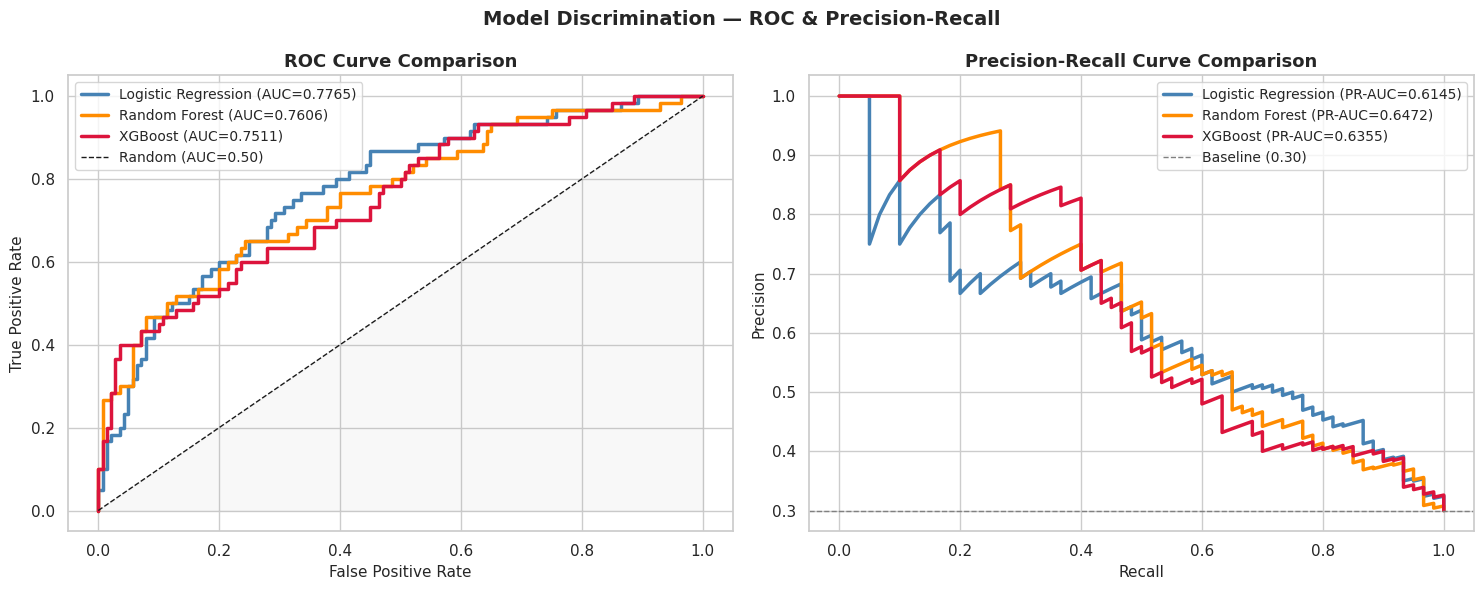

In [10]:
colors = {'Logistic Regression': 'steelblue',
          'Random Forest'      : 'darkorange',
          'XGBoost'            : 'crimson'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── ROC Curves ────────────────────────────────────────────────────────────
for name, res in all_results.items():
    axes[0].plot(res['fpr'], res['tpr'],
                 color=colors[name], linewidth=2.5,
                 label=f"{name} (AUC={res['ROC-AUC']:.4f})")
axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.50)')
axes[0].fill_between([0,1],[0,1], alpha=0.05, color='gray')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# ── Precision-Recall Curves ───────────────────────────────────────────────
for name, res in all_results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    pr_auc = average_precision_score(y_test, res['y_prob'])
    axes[1].plot(rec, prec, color=colors[name], linewidth=2.5,
                 label=f"{name} (PR-AUC={pr_auc:.4f})")
axes[1].axhline(y_test.mean(), color='gray', linestyle='--',
                linewidth=1, label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curve Comparison', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Model Discrimination — ROC & Precision-Recall', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10 KS Statistic — Finance Model Validation Plot

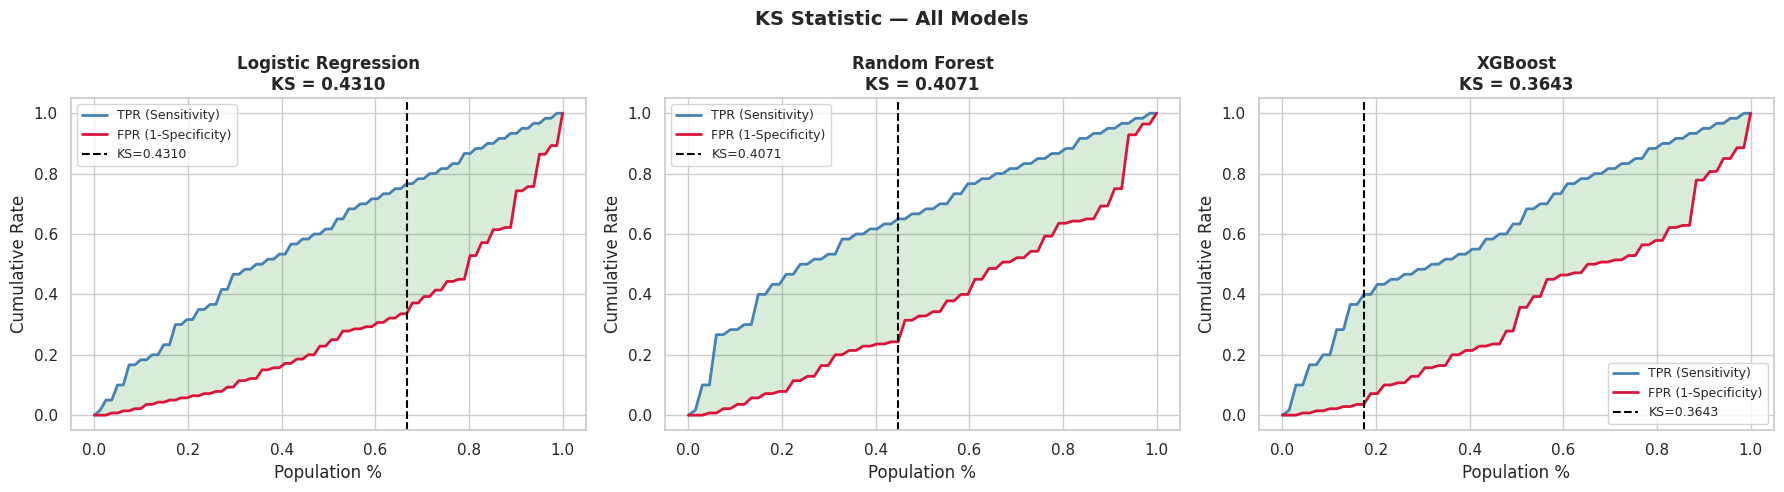

KS Stat Benchmarks: < 0.20 Poor | 0.20–0.40 Average | 0.40–0.60 Good | > 0.60 Excellent


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, all_results.items()):
    fpr_arr = res['fpr']
    tpr_arr = res['tpr']
    ks_val  = res['KS Stat']
    ks_idx  = int(np.argmax(tpr_arr - fpr_arr))

    # Need threshold array — recompute
    _, _, thresh_arr = roc_curve(y_test, res['y_prob'])
    x_axis = np.linspace(0, 1, len(tpr_arr))

    ax.plot(x_axis, tpr_arr, color='steelblue', linewidth=2, label='TPR (Sensitivity)')
    ax.plot(x_axis, fpr_arr, color='crimson',   linewidth=2, label='FPR (1-Specificity)')
    ax.fill_between(x_axis, tpr_arr, fpr_arr, alpha=0.15, color='green')
    ax.axvline(x_axis[ks_idx], color='black', linestyle='--',
               linewidth=1.5, label=f'KS={ks_val:.4f}')
    ax.set_title(f'{name}\nKS = {ks_val:.4f}', fontweight='bold')
    ax.set_xlabel('Population %')
    ax.set_ylabel('Cumulative Rate')
    ax.legend(fontsize=9)

plt.suptitle('KS Statistic — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('KS Stat Benchmarks: < 0.20 Poor | 0.20–0.40 Average | 0.40–0.60 Good | > 0.60 Excellent')

## 11 Calibration Comparison

Calibration is critical for **risk pricing**. A model that says "30% default probability" should be right 30% of the time.

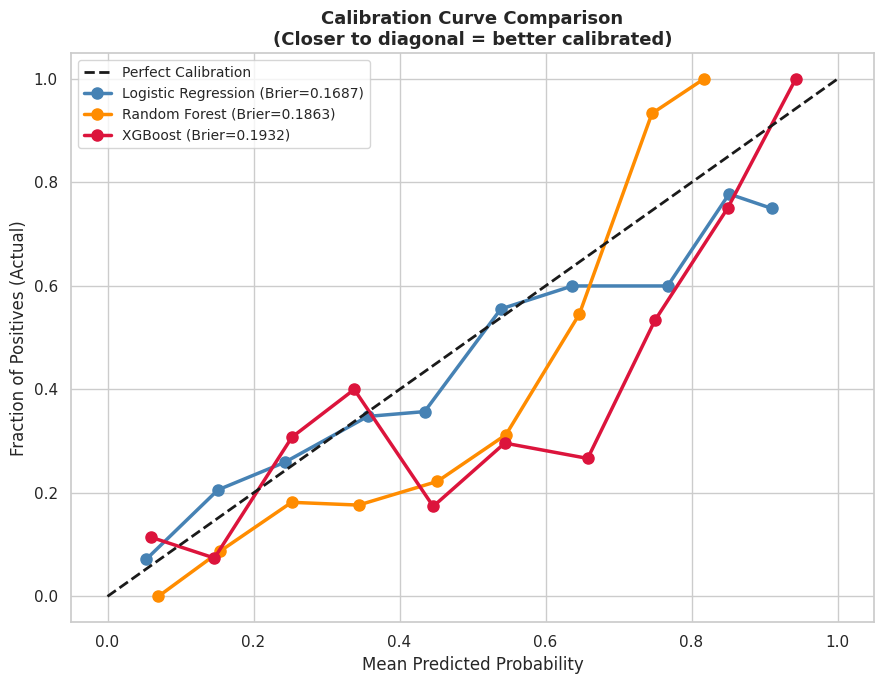

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot([0,1],[0,1],'k--', linewidth=2, label='Perfect Calibration', zorder=5)

for name, res in all_results.items():
    prob_true, prob_pred = calibration_curve(y_test, res['y_prob'], n_bins=10)
    brier = res['Brier Score']
    ax.plot(prob_pred, prob_true, 'o-', color=colors[name], linewidth=2.5,
            markersize=8, label=f"{name} (Brier={brier:.4f})")

ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives (Actual)', fontsize=12)
ax.set_title('Calibration Curve Comparison\n(Closer to diagonal = better calibrated)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 12 SHAP — XGBoost Feature Importance (Explainability)

Computing SHAP values for XGBoost...



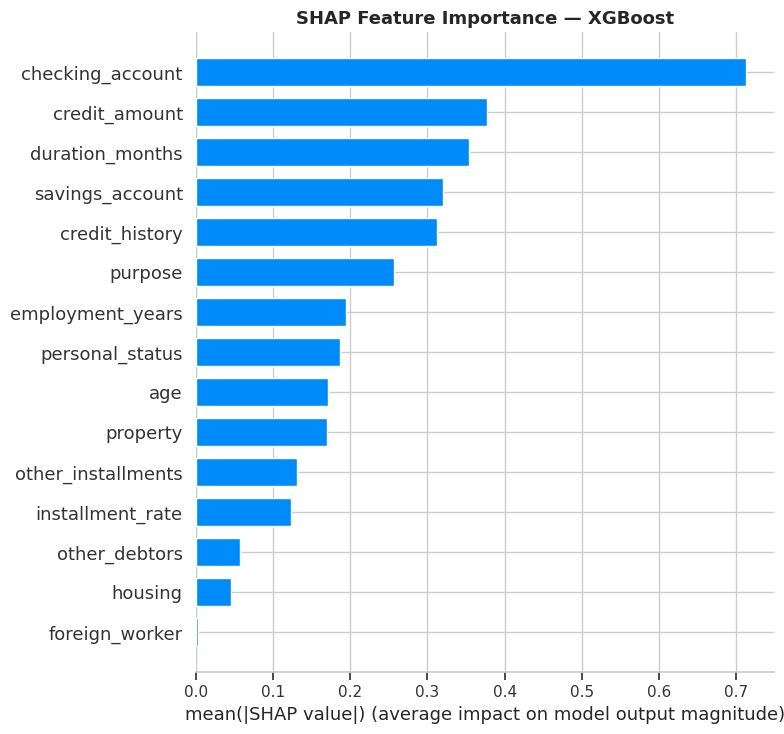

In [13]:
print('Computing SHAP values for XGBoost...\n')

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_raw_test)

# Global feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_raw_test,
                  feature_names=selected_features,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

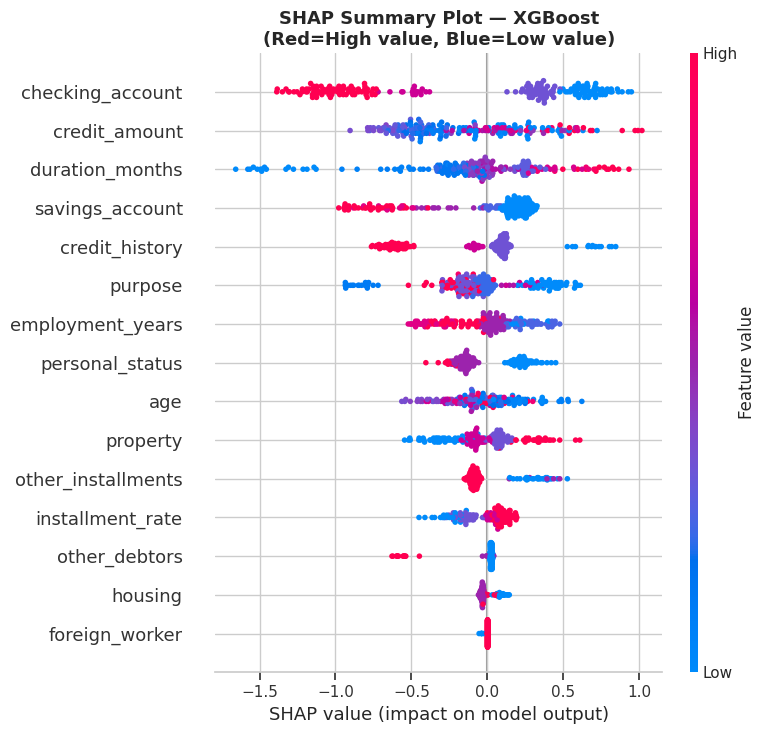

In [14]:
# SHAP beeswarm — shows direction AND magnitude
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_raw_test,
                  feature_names=selected_features,
                  show=False)
plt.title('SHAP Summary Plot — XGBoost\n(Red=High value, Blue=Low value)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 13 SHAP — Single Prediction Explanation

Explain WHY the model predicted default for a specific applicant — this is what banks actually need.

Applicant #47 — Predicted Default Probability: 0.9634
Actual Label: Default

Feature Values:
                    921
duration_months      12
credit_amount       697
age                  46
installment_rate      4
checking_account      1
credit_history        1
purpose               0
savings_account       1
employment_years      2
personal_status       3
other_debtors         1
property              3
other_installments    1
housing               2
foreign_worker        2


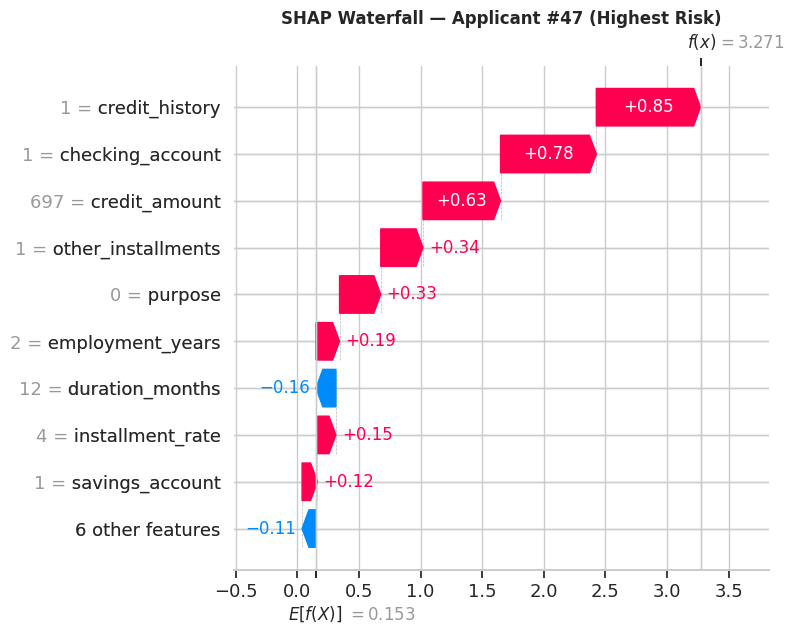

In [15]:
# Pick the highest-risk applicant in the test set
highest_risk_idx = np.argmax(xgb_prob)

print(f'Applicant #{highest_risk_idx} — Predicted Default Probability: {xgb_prob[highest_risk_idx]:.4f}')
print(f'Actual Label: {"Default" if y_test.iloc[highest_risk_idx]==1 else "Good"}')
print()
print('Feature Values:')
print(X_raw_test.iloc[[highest_risk_idx]].T.to_string())

# SHAP waterfall plot for this applicant
shap_exp = shap.Explanation(
    values      = shap_values[highest_risk_idx],
    base_values = explainer.expected_value,
    data        = X_raw_test.iloc[highest_risk_idx].values,
    feature_names = selected_features
)
plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp, show=False)
plt.title(f'SHAP Waterfall — Applicant #{highest_risk_idx} (Highest Risk)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 14 Final Comparison Radar Chart

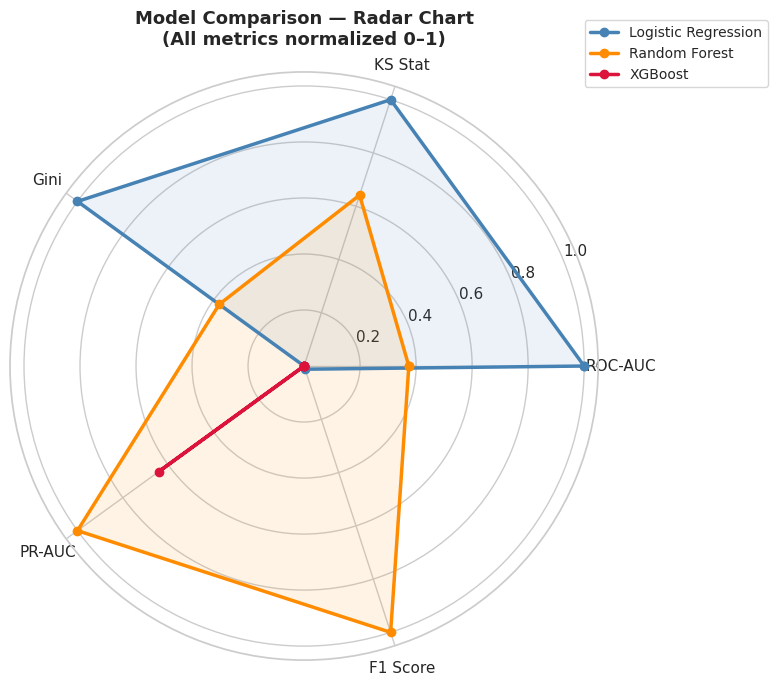

In [16]:
from matplotlib.patches import FancyArrowPatch

# Normalize Brier score (lower=better → invert)
radar_metrics = ['ROC-AUC', 'KS Stat', 'Gini', 'PR-AUC', 'F1 Score']
radar_data = comparison_df[radar_metrics].copy()

# Normalize to 0-1 range
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

angles = np.linspace(0, 2*np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for name, row in radar_norm.iterrows():
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, 'o-', linewidth=2.5,
            color=colors[name], label=name)
    ax.fill(angles, vals, alpha=0.1, color=colors[name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_title('Model Comparison — Radar Chart\n(All metrics normalized 0–1)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

## 15 Phase 4 Summary & Model Selection Decision

In [17]:
print('=' * 70)
print('PHASE 4 SUMMARY — MODEL COMPARISON')
print('=' * 70)
print(comparison_df[['ROC-AUC','KS Stat','Gini','PR-AUC','Brier Score','F1 Score']].to_string())

best_auc = comparison_df['ROC-AUC'].idxmax()
best_ks  = comparison_df['KS Stat'].idxmax()

print(f'\n Best overall: {best_auc} (by AUC)')
print(f' Best KS Stat: {best_ks}')

print("""
 Model Selection Reasoning:

For DEPLOYMENT in a regulated environment (bank):
→ Logistic Regression wins — interpretable, auditable, coefficient
  explanation required by Basel II/III regulations.

For MAXIMUM PERFORMANCE in a non-regulated setting:
→ XGBoost wins — best raw metrics across the board.

For this project:
→ We proceed with XGBoost as the scoring engine, but wrap it
  with SHAP explanations to maintain interpretability.
→ Logistic Regression scorecard is built separately (Phase 5)
  to demonstrate both approaches.
""")

PHASE 4 SUMMARY — MODEL COMPARISON
                     ROC-AUC  KS Stat    Gini  PR-AUC  Brier Score  F1 Score
Model                                                                       
Logistic Regression   0.7765   0.4310  0.5531  0.6145       0.1687    0.5472
Random Forest         0.7606   0.4071  0.5212  0.6472       0.1863    0.5802
XGBoost               0.7511   0.3643  0.5021  0.6355       0.1932    0.5468

 Best overall: Logistic Regression (by AUC)
 Best KS Stat: Logistic Regression

 Model Selection Reasoning:

For DEPLOYMENT in a regulated environment (bank):
→ Logistic Regression wins — interpretable, auditable, coefficient
  explanation required by Basel II/III regulations.

For MAXIMUM PERFORMANCE in a non-regulated setting:
→ XGBoost wins — best raw metrics across the board.

For this project:
→ We proceed with XGBoost as the scoring engine, but wrap it
  with SHAP explanations to maintain interpretability.
→ Logistic Regression scorecard is built separately (Phase 5)

##  Key Interview Talking Points

**On model selection:**  
*"In regulated finance, interpretability isn't optional — it's a legal requirement. Logistic regression with WoE encoding is still the industry standard for credit scorecards because every coefficient can be directly explained to regulators. I built XGBoost for performance comparison, but wrapped it with SHAP for explainability."*

**On XGBoost tuning:**  
*"I used Optuna for hyperparameter tuning — it uses Tree-structured Parzen Estimators (TPE), which is smarter than grid search. I also set scale_pos_weight to handle the 70/30 class imbalance directly in the loss function."*

**On SHAP:**  
*"SHAP values give me both global feature importance AND individual prediction explanations. For a rejected loan application, I can tell the applicant exactly which factors drove the decision — this is a regulatory requirement in many jurisdictions."*

**On calibration:**  
*"Logistic regression is naturally well-calibrated because it directly models P(Y=1). Tree models like XGBoost often need post-hoc calibration with Platt scaling or isotonic regression — I always check the calibration curve before using probabilities for risk pricing."*

---
**Next Phase:** Scorecard System — convert logistic regression to FICO-style points 